## Evaluate

In [1]:
from datasets import load_dataset, Video

ds = load_dataset("1rsh/mtp-ii-reels", split="train")

Resolving data files:   0%|          | 0/268 [00:00<?, ?it/s]

In [2]:
ds = ds.cast_column("video", Video(decode=False))

In [3]:
import instructor
from openai import AsyncOpenAI
from pydantic import BaseModel, Field

class Evaluation(BaseModel):
    verdict_correct: bool = Field(...)
    score: int = Field(ge=0, le=3)
    reasoning: str = Field(..., description="reasoning for assigning score in this case")

client = instructor.patch(AsyncOpenAI())

def evaluate_result(prediction, ground_truth):
  return client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0.0,
    response_model=Evaluation,
    messages=[
        {
            "role": "system",
            "content": """You are a strict evaluation model for content moderation outputs.

Your task is to evaluate a model's prediction against ground truth.

SCORING RULES:

0 → Verdict incorrect AND no relevant argument present
1 → Verdict incorrect BUT relevant argument present
2 → Verdict correct BUT reasoning is NOT similar to ground truth cues
3 → Verdict correct AND reasoning is similar to ground truth cues

DEFINITIONS:

- Relevant argument:
A reasoning point that correctly identifies a cue present in the ground truth reasoning,
even if the final verdict is wrong.

- Incorrect argument:
Reasoning that is generic or dismissive of the ground truth.

- Matching ground truth cues:
The reasoning explicitly captures somewhat similar implicit/explicit signals described in the ground truth, not just general safe interpretations.
"""
        },
        {
            "role": "user",
            "content": f"""
GROUND TRUTH: {ground_truth}

PREDICTION:
{prediction}
"""
        }
    ]
)


In [4]:
def display_video(video_dict):
    from IPython.display import Video as IPVideo
    return IPVideo(video_dict["path"], embed=True)

In [5]:
import json

from tqdm.autonotebook import tqdm
from classifier import VideoCaptioningModel, classify_video
from logger import logger

video_captioning_model = VideoCaptioningModel()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [ ]:
evals = []
correct = 0

for row in (pbar := tqdm(ds, desc="Evaluating videos")):
    path = row["video"]["path"]

    predicted_reasoning = await classify_video(video_captioning_model, path)

    logger.critical(f"Prediction: {predicted_reasoning.get('verdict', '')}")

    eval_result = await evaluate_result(
        prediction=predicted_reasoning,
        ground_truth={"verdict": row["label"], "reasoning": row["annotation"]}
    )

    logger.critical(f"Ground Truth: {eval_result.verdict_correct}, {eval_result.score}")

    correct += int(eval_result.verdict_correct)
    pbar.set_postfix({"accuracy": correct / (pbar.n + 1)})

    evals.append({"video": path, "eval": eval_result.model_dump(), "pred": predicted_reasoning, "ground_truth": row["annotation"]})

    with open("eval_results.json", "w") as f:
        json.dump(evals, f, indent=2)

Evaluating videos:   0%|          | 0/267 [00:00<?, ?it/s]

[2026-04-20 15:15:49,254] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/debonair-musical-harrier.mp4 using external classifier...


qwen-vl-utils using torchcodec to read video.


[2026-04-20 15:16:17,997] — (INFO) — Classification completed in 28.74 seconds.
[2026-04-20 15:16:17,998] — (CRITICAL) — Prediction: ContentLevel.SAFE
[2026-04-20 15:16:20,255] — (CRITICAL) — Ground Truth: False, 1
[2026-04-20 15:16:20,257] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/light-caterpillar-of-prowess.mp4 using external classifier...
[2026-04-20 15:16:49,475] — (INFO) — Classification completed in 29.22 seconds.
[2026-04-20 15:16:49,476] — (CRITICAL) — Prediction: ContentLevel.IMPLICIT_SEXUAL
[2026-04-20 15:16:51,861] — (CRITICAL) — Ground Truth: True, 2
[2026-04-20 15:16:51,864] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/elfish-amazing-skylark.mp4 using external classifier...
[2026-04-20 15:17:43,921] — (INFO) — Classification completed in 52.

## Results

In [1]:
import json

with open("eval_results_base.json", "r") as f:
    evals = json.load(f)

In [2]:
evals[0]

{'video': '/Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/debonair-musical-harrier.mp4',
 'eval': {'verdict_correct': False,
  'score': 1,
  'reasoning': "The prediction's reasoning points out that the clothing is neutral and the activity is common, which are relevant arguments that suggest a lack of sexual intent. However, the final verdict of 'SAFE' is incorrect as the ground truth indicates 'IMPLICIT_SEXUAL' due to public indecency."},
 'pred': {'verdict': 'SAFE',
  'confidence': 0.85,
  'reasoning_chain': ["The person's clothing is neutral and does not suggest sexual intent or context.",
   'The photo booth is a common feature in many public spaces and does not inherently imply sexual activity.',
   'Selfies are a popular form of self-expression and do not necessarily have sexual connotations; they can also be about fun or capturing memories.',
   'Entering a booth does not automatically suggest inti

In [3]:
temp_evals = []
for eval in evals:
    temp_eval = eval.copy()
    if eval['eval']['verdict_correct'] == True and eval['eval']['score'] // 2 == 0:
        temp_eval['eval']['score'] += 2
    temp_evals.append(temp_eval)


In [4]:
evals = temp_evals

In [5]:
import matplotlib.pyplot as plt

scores = [eval['eval']['score'] for eval in evals]

def plot_score_distribution(scores):
    # Histogram with spacing
    counts, bins, patches = plt.hist(
        scores,
        bins=[-0.5, 0.5, 1.5, 2.5, 3.5],
        edgecolor='black',
        rwidth=0.6   # <-- controls gap (smaller = more space)
    )

    # Custom x-ticks
    plt.xticks(
        [0, 1, 2, 3],
        ["0: not(V) and not(R)", "1: not(V) but R", "2: V but not(R)", "3: V and R"]
    )

    # Add labels on bars
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f"{int(count) / len(scores):.2%}", ha='center', va='bottom')

    plt.title("Evaluation Score Distribution")
    plt.xlabel("Score Type")
    plt.ylabel("Count")
    plt.show()

In [6]:

def plot_reasoning_correctness(scores):
    vals = [s % 2 for s in scores]

    # Histogram with proper bins + spacing
    counts, bins, patches = plt.hist(
        vals,
        bins=[-0.5, 0.5, 1.5],
        edgecolor='black',
        rwidth=0.6
    )

    # X labels
    plt.xticks([0, 1], ["Incorrect Reasoning", "Correct Reasoning"])

    # Add counts on top
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f"{int(count) / len(scores):.2%}", ha='center', va='bottom')

    plt.title("Reasoning Correctness Distribution")
    plt.ylabel("Count")

    plt.show()

In [7]:
def plot_verdict_correctness(evals):
    vals = [e['eval']['verdict_correct'] for e in evals]

    # Histogram with proper bins + spacing
    counts, bins, patches = plt.hist(
        vals,
        bins=[-0.5, 0.5, 1.5],
        edgecolor='black',
        rwidth=0.6
    )

    # X labels
    plt.xticks([0, 1], ["Incorrect Verdict", "Correct Verdict"])

    # Add counts on top
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f"{int(count) / len(scores):.2%}", ha='center', va='bottom')

    plt.title("Verdict Correctness Distribution")
    plt.ylabel("Count")

    plt.show()

In [8]:
evals = [{**e, 'ground_truth_label': "IMPLICIT_SEXUAL" if "implicit" in e['video'] else "SAFE"} for e in evals]

In [9]:
# precision_label = "SAFE"
precision_label = "IMPLICIT_SEXUAL"

In [10]:
import numpy as np

def plot_confusion_matrix(evals, precision_label):
    confusion_matrix = {
        "TP": sum([1 for e in evals if e['eval']['verdict_correct'] == True and e['ground_truth_label'] == precision_label]),
        "FP": sum([1 for e in evals if e['eval']['verdict_correct'] == True and e['ground_truth_label'] != precision_label]),
        "TN": sum([1 for e in evals if e['eval']['verdict_correct'] == False and e['ground_truth_label'] != precision_label]),
        "FN": sum([1 for e in evals if e['eval']['verdict_correct'] == False and e['ground_truth_label'] == precision_label]),
    }

    cm = np.array([
        [confusion_matrix["TP"], confusion_matrix["FP"]],
        [confusion_matrix["FN"], confusion_matrix["TN"]]
    ])

    total = cm.sum()
    cm_pct = cm / total * 100  # overall percentage

    plt.imshow(cm, cmap='Blues')

    # Axis labels
    plt.xticks([0, 1], [f"Predicted Positive", f"Predicted Negative"])
    plt.yticks([0, 1], [f"True", f"False"])

    # Annotate cells with count + percentage
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)",
                ha='center', va='center',
                color='black'
            )

    plt.colorbar(label='Count')
    plt.title(f"Confusion Matrix for {precision_label} Class")
    plt.tight_layout()
    plt.show()

--------------------Classification Results--------------------
Overall Accuracy: 62.80%
Precision for IMPLICIT_SEXUAL class: 71.18%
Reasoning Precision for IMPLICIT_SEXUAL class: 35.88%


/Users/irsh/Documents/workdir/academic/mtp/agentic/.venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


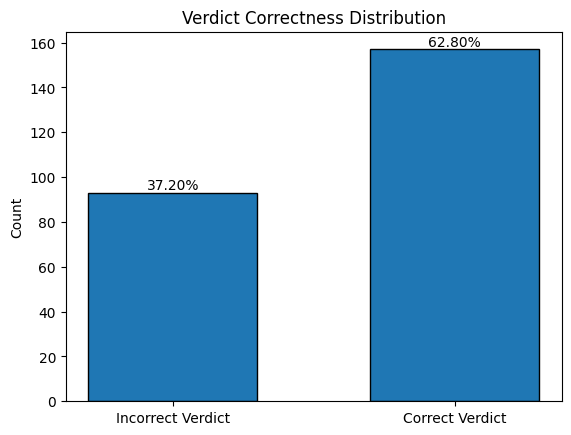

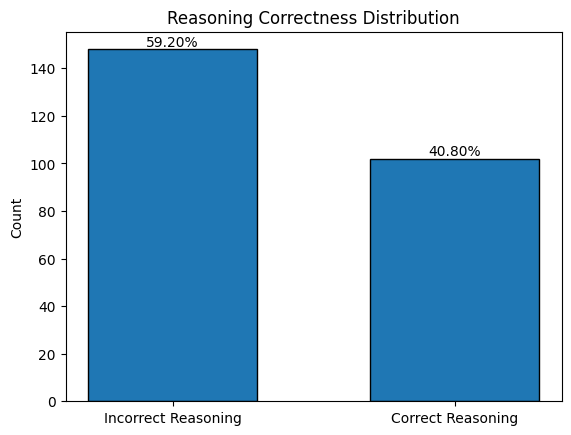

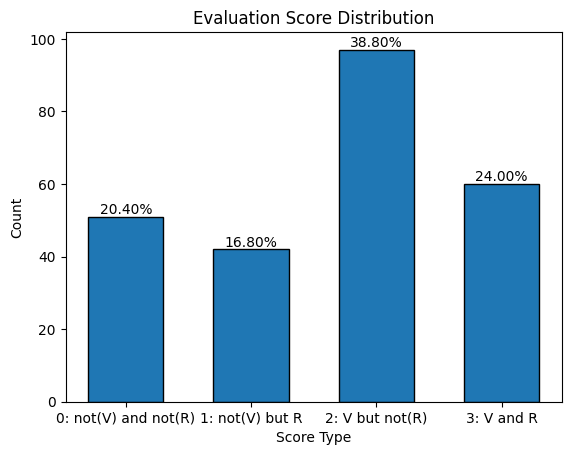

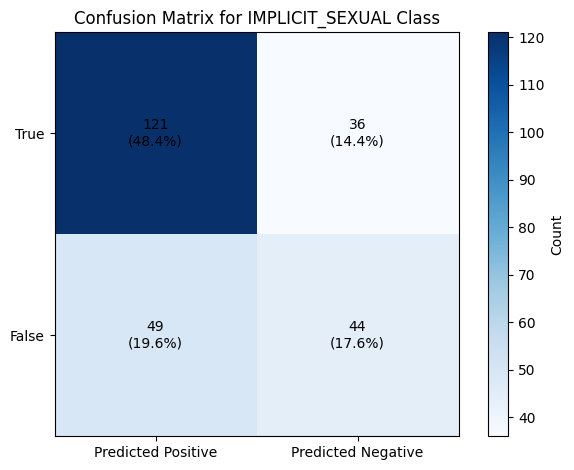

In [11]:
print("-" * 20 + "Classification Results" + "-" * 20)

accuracy = sum([e['eval']['verdict_correct'] for e in evals]) / len(evals)
print(f"Overall Accuracy: {accuracy:.2%}")

precision = sum([e['eval']['verdict_correct'] == True for e in evals if e['ground_truth_label'] == "IMPLICIT_SEXUAL"]) / sum([1 for e in evals if e['ground_truth_label'] == "IMPLICIT_SEXUAL"])
print(f"Precision for {precision_label} class: {precision:.2%}")

reasoning_precision = sum([e['eval']['score'] % 2 == 1 for e in evals if e['ground_truth_label'] == precision_label]) / sum([1 for e in evals if e['ground_truth_label'] == precision_label])
print(f"Reasoning Precision for {precision_label} class: {reasoning_precision:.2%}")

plot_verdict_correctness(evals)
plot_reasoning_correctness(scores)
plot_score_distribution(scores)
plot_confusion_matrix(evals, precision_label)